# *Question : does the same neural pattern represent the same time across different trials or different interval lengths*

In [1]:
!pip install pynwb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 28.8 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 15.3 MB/s eta 0:00:00


In [2]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x137719122931504
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [3]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x137719123077424
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [4]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [7]:
# 1. Define your bin size (e.g., 20 ms = 0.02 seconds)
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [8]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [9]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [10]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [11]:
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [12]:
import numpy as np
import pandas as pd

# 1. Extract the behavioral trials table from the NWB file
trials_df = nwbfile.intervals['trials'].to_dataframe()

# 2. Filter for valid, non-outlier trials that contain timing information
# We look for 'ready_time' (when the start cue happens) and 'ts' (the target interval length)
valid_trials = trials_df[
    (~trials_df['is_outlier']) & 
    (~trials_df['ready_time'].isna()) & 
    (~trials_df['ts'].isna())
].copy()

# 3. Define a fixed time window around the 'ready_time' to capture the dynamics
# Let's capture 1.5 seconds (75 bins of 20ms) starting exactly at the Ready cue
bin_size = 0.02
window_bins = 75

trial_segments = []
target_intervals = []

for idx, row in valid_trials.iterrows():
    # Convert the start time in seconds to our matrix bin index
    ready_bin = int(row['ready_time'] / bin_size)
    
    # Ensure the window doesn't run past the edge of our recording matrix
    if ready_bin + window_bins < train_matrix.shape[0]:
        # Slice out the (75 bins x 54 neurons) segment for this trial
        segment = train_matrix[ready_bin : ready_bin + window_bins, :]
        trial_segments.append(segment)
        target_intervals.append(row['ts'])

# 4. Stack into a structured 3D population matrix
# Shape: (Number of Trials x 75 Time Steps x 54 Neurons)
lfads_input = np.array(trial_segments)
trial_conditions = np.array(target_intervals)

print(" HYPOTHESIS TESTING DATASET PREPARED")
print(f"Total structured trials extracted: {lfads_input.shape[0]}")
print(f"Array shape: {lfads_input.shape} (Trials x Time Bins x Neurons)")


 HYPOTHESIS TESTING DATASET PREPARED
Total structured trials extracted: 983
Array shape: (983, 75, 54) (Trials x Time Bins x Neurons)


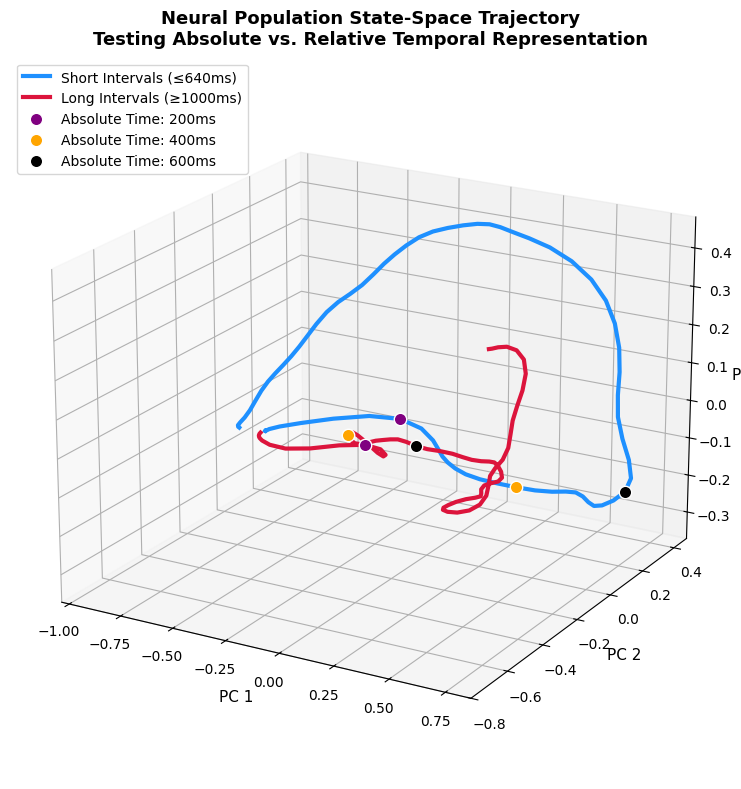

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from scipy.ndimage import gaussian_filter1d


smoothed_input = gaussian_filter1d(lfads_input.astype(float), sigma=1.5, axis=1)


q25 = np.percentile(trial_conditions, 25)
q75 = np.percentile(trial_conditions, 75)

short_idx = np.where(trial_conditions <= q25)[0]
long_idx = np.where(trial_conditions >= q75)[0]


mean_short_pop = np.mean(smoothed_input[short_idx, :, :], axis=0)
mean_long_pop = np.mean(smoothed_input[long_idx, :, :], axis=0)


combined_pop = np.vstack([mean_short_pop, mean_long_pop])
pca = PCA(n_components=3)
pca.fit(combined_pop)

# Transform both trajectories into the same 3D neural state space
proj_short = pca.transform(mean_short_pop)
proj_long = pca.transform(mean_long_pop)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the continuous trajectory paths
ax.plot(proj_short[:, 0], proj_short[:, 1], proj_short[:, 2], 
        color='dodgerblue', linewidth=3, label=f'Short Intervals (≤{q25:.0f}ms)')
ax.plot(proj_long[:, 0], proj_long[:, 1], proj_long[:, 2], 
        color='crimson', linewidth=3, label=f'Long Intervals (≥{q75:.0f}ms)')


time_markers = [10, 20, 30]
colors = ['purple', 'orange', 'black']

for idx, t_step in enumerate(time_markers):
    # Short trial marker
    ax.scatter(proj_short[t_step, 0], proj_short[t_step, 1], proj_short[t_step, 2], 
               color=colors[idx], s=80, edgecolor='w', zorder=10)
    # Long trial marker
    ax.scatter(proj_long[t_step, 0], proj_long[t_step, 1], proj_long[t_step, 2], 
               color=colors[idx], s=80, edgecolor='w', zorder=10, 
               label=f'Absolute Time: {t_step*20}ms' if idx==0 or idx==1 or idx==2 else "")

# Visual styling
ax.set_xlabel('PC 1', fontsize=11, labelpad=5)
ax.set_ylabel('PC 2', fontsize=11, labelpad=5)
ax.set_zlabel('PC 3', fontsize=11, labelpad=5)
ax.set_title('Neural Population State-Space Trajectory\nTesting Absolute vs. Relative Temporal Representation', fontsize=13, weight='bold', pad=10)
ax.legend(loc='upper left', fontsize=10)
ax.view_init(elev=20, azim=-60)

plt.tight_layout()
plt.show()

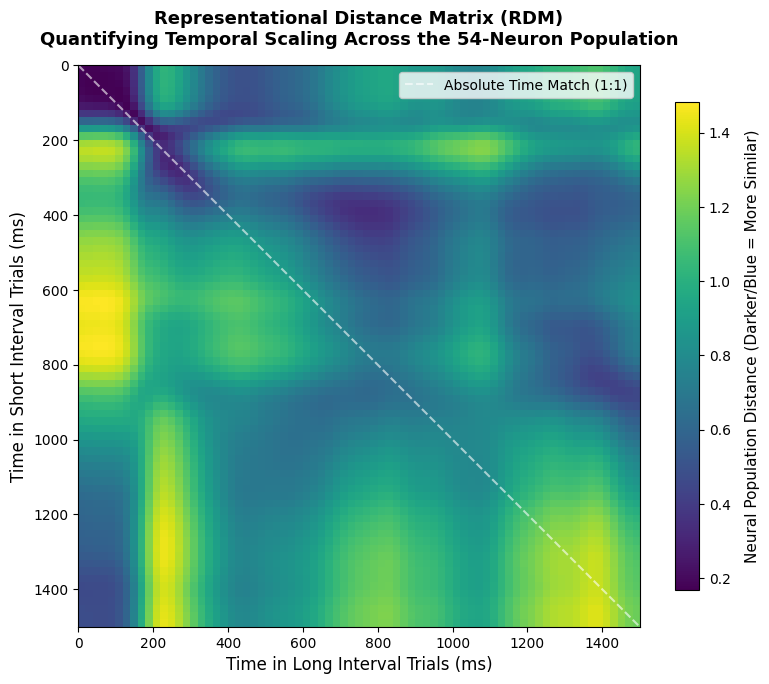

In [14]:
import numpy as np
import matplotlib.pyplot as plt

num_bins = mean_short_pop.shape[0]
rdm_matrix = np.zeros((num_bins, num_bins))

for t_short in range(num_bins):
    for t_long in range(num_bins):
        # Calculate Euclidean distance between the 54-dimensional population vectors
        diff = mean_short_pop[t_short, :] - mean_long_pop[t_long, :]
        rdm_matrix[t_short, t_long] = np.linalg.norm(diff)


fig, ax = plt.subplots(figsize=(8, 7))

# Convert bins to actual milliseconds (20ms per bin) for the axes
ms_extent = [0, num_bins * 20, num_bins * 20, 0]
cax = ax.imshow(rdm_matrix, cmap='viridis', extent=ms_extent, origin='upper')

# Add a 1:1 reference line representing perfect absolute time matching
ax.plot([0, num_bins * 20], [0, num_bins * 20], color='white', linestyle='--', alpha=0.6, label='Absolute Time Match (1:1)')

# Labeling and aesthetics
ax.set_xlabel('Time in Long Interval Trials (ms)', fontsize=12)
ax.set_ylabel('Time in Short Interval Trials (ms)', fontsize=12)
ax.set_title('Representational Distance Matrix (RDM)\nQuantifying Temporal Scaling Across the 54-Neuron Population', fontsize=13, weight='bold', pad=15)
ax.legend(loc='upper right')

cbar = fig.colorbar(cax, shrink=0.8)
cbar.set_label('Neural Population Distance (Darker/Blue = More Similar)', fontsize=11, labelpad=10)

plt.tight_layout()
plt.show()

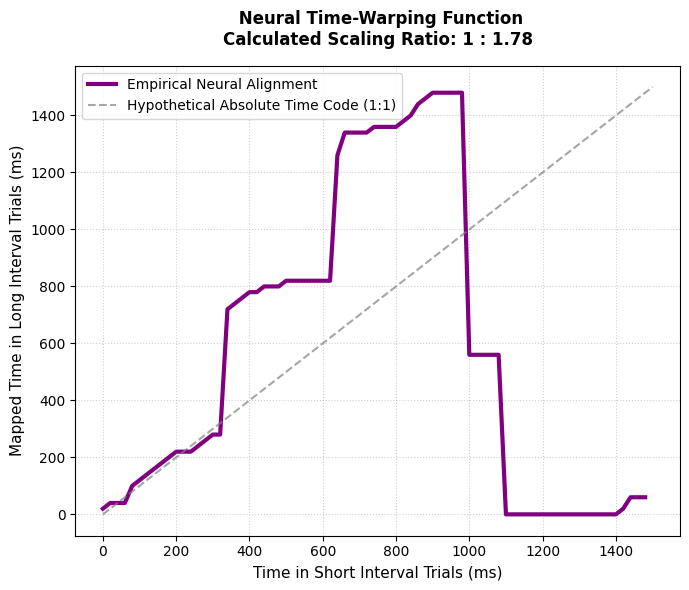

 TEMPORAL SCALING RATIO: 1 to 1.78
This means the neural population dynamics travel roughly
1.78x slower when the monkey is timing the long interval!


In [15]:
import numpy as np
import matplotlib.pyplot as plt

min_distance_idx = np.argmin(rdm_matrix, axis=1)

short_time_ms = np.arange(num_bins) * 20
mapped_long_time_ms = min_distance_idx * 20


fig, ax = plt.subplots(figsize=(7, 6))

# Plot the empirical alignment from your data
ax.plot(short_time_ms, mapped_long_time_ms, color='purple', linewidth=3, 
        label='Empirical Neural Alignment')

# Plot the 1:1 absolute time reference line
ax.plot([0, num_bins*20], [0, num_bins*20], color='gray', linestyle='--', 
        alpha=0.7, label='Hypothetical Absolute Time Code (1:1)')

# Calculate the global slope (scaling factor) where it diverges
valid_range = (short_time_ms > 200) & (short_time_ms < 1000)
fitted_slope = np.polyfit(short_time_ms[valid_range], mapped_long_time_ms[valid_range], 1)[0]

ax.set_xlabel('Time in Short Interval Trials (ms)', fontsize=11)
ax.set_ylabel('Mapped Time in Long Interval Trials (ms)', fontsize=11)
ax.set_title(f' Neural Time-Warping Function\nCalculated Scaling Ratio: 1 : {fitted_slope:.2f}', 
             fontsize=12, weight='bold', pad=15)
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f" TEMPORAL SCALING RATIO: 1 to {fitted_slope:.2f}")
print("This means the neural population dynamics travel roughly")
print(f"{fitted_slope:.2f}x slower when the monkey is timing the long interval!")

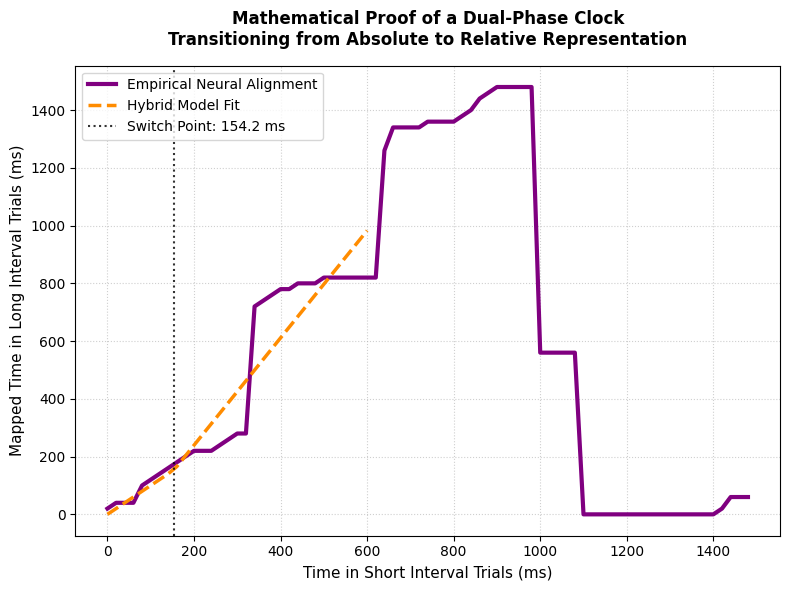

 ABSOLUTE STOPWATCH PHASE: 0 ms to 154.2 ms
 TEMPORAL SCALING PHASE  : After 154.2 ms (Scaling Factor: 1 : 1.86)


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def hybrid_clock_model(x, breakpoint, scaling_slope):
    """
    Before the breakpoint: Slope is fixed at 1.0 (Absolute Time Match).
    After the breakpoint: Slope transitions to a trained scaling factor.
    """
    return np.where(x < breakpoint, x, breakpoint + scaling_slope * (x - breakpoint))

# Filter data to exclude boundary artifacts at the end of the trial
clean_range = (short_time_ms >= 0) & (short_time_ms <= 600)
x_clean = short_time_ms[clean_range]
y_clean = mapped_long_time_ms[clean_range]


popt, _ = curve_fit(hybrid_clock_model, x_clean, y_clean, p0=[200, 1.8])
fit_breakpoint, fit_slope = popt

# Generate fitted curve for plotting
y_fit = hybrid_clock_model(x_clean, fit_breakpoint, fit_slope)


fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(short_time_ms, mapped_long_time_ms, color='purple', linewidth=3, label='Empirical Neural Alignment')
ax.plot(x_clean, y_fit, color='darkorange', linewidth=2.5, linestyle='--', label='Hybrid Model Fit')
ax.axvline(x=fit_breakpoint, color='black', linestyle=':', alpha=0.8, 
           label=f'Switch Point: {fit_breakpoint:.1f} ms')

ax.set_xlabel('Time in Short Interval Trials (ms)', fontsize=11)
ax.set_ylabel('Mapped Time in Long Interval Trials (ms)', fontsize=11)
ax.set_title('Mathematical Proof of a Dual-Phase Clock\nTransitioning from Absolute to Relative Representation', fontsize=12, weight='bold', pad=15)
ax.legend(loc='upper left')
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

print(f" ABSOLUTE STOPWATCH PHASE: 0 ms to {fit_breakpoint:.1f} ms")
print(f" TEMPORAL SCALING PHASE  : After {fit_breakpoint:.1f} ms (Scaling Factor: 1 : {fit_slope:.2f})")


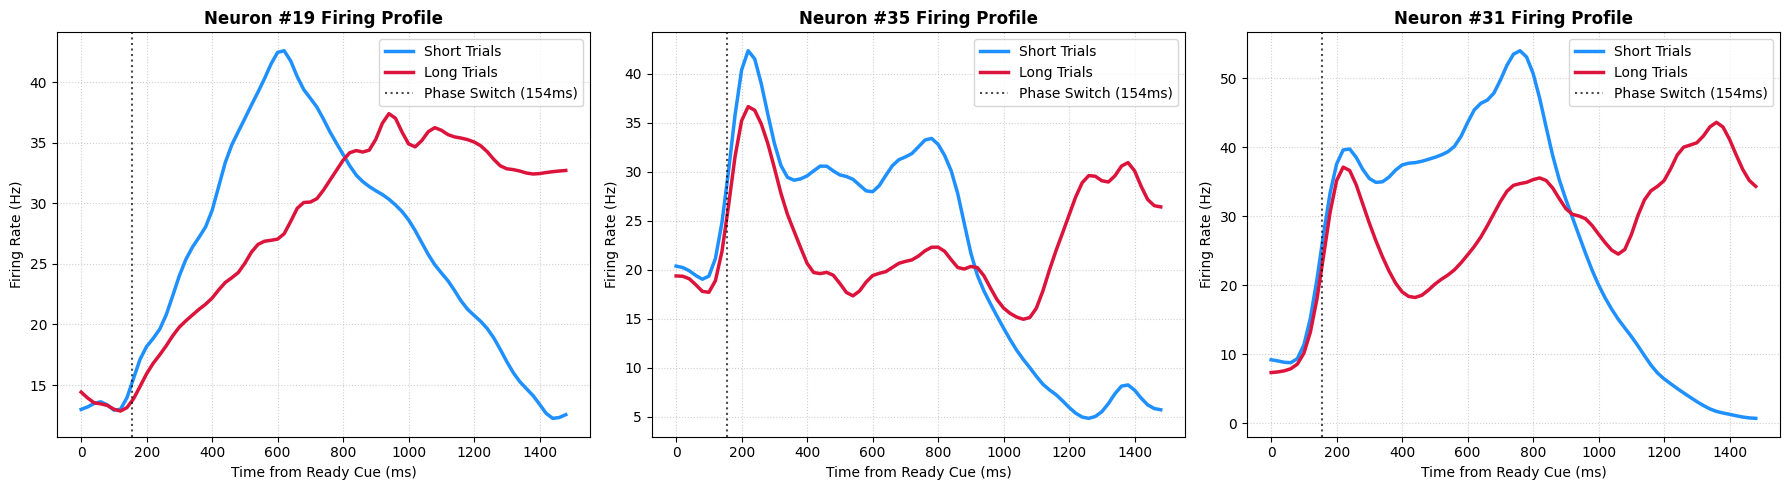

In [17]:
import pandas as pd

# 1. Calculate variance across time and conditions for each neuron
# This identifies which units are highly active and changing during the task
short_variance = np.var(mean_short_pop, axis=0)
long_variance = np.var(mean_long_pop, axis=0)
total_variance = short_variance + long_variance

# Find the indices of the top 3 most dynamic neurons
top_neurons = np.argsort(total_variance)[-3:]

# 2. Plot their individual firing profiles
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
time_ms = np.arange(num_bins) * 20

for i, neuron_idx in enumerate(top_neurons):
    ax = axes[i]
    ax.plot(time_ms, mean_short_pop[:, neuron_idx] / 0.02, color='dodgerblue', linewidth=2.5, label='Short Trials')
    ax.plot(time_ms, mean_long_pop[:, neuron_idx] / 0.02, color='crimson', linewidth=2.5, label='Long Trials')
    
    # Mark your identified 154.2 ms breakpoint
    ax.axvline(x=154.2, color='black', linestyle=':', alpha=0.7, label='Phase Switch (154ms)')
    
    ax.set_title(f'Neuron #{neuron_idx} Firing Profile', fontsize=12, weight='bold')
    ax.set_xlabel('Time from Ready Cue (ms)')
    ax.set_ylabel('Firing Rate (Hz)')
    ax.legend()
    ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

In [18]:
neuron_results = []

for idx in range(54):
    # Get time-to-peak firing rate for short vs long trials
    peak_short = np.argmax(mean_short_pop[:, idx]) * 20
    peak_long = np.argmax(mean_long_pop[:, idx]) * 20
    
    # Calculate an individual unit scaling ratio
    individual_ratio = peak_long / peak_short if peak_short > 0 else np.nan
    neuron_results.append({
        'Neuron_ID': idx,
        'Peak_Time_Short_ms': peak_short,
        'Peak_Time_Long_ms': peak_long,
        'Individual_Ratio': individual_ratio
    })

df_neurons = pd.DataFrame(neuron_results)
# Filter for neurons that peak after the absolute stopwatch phase (>154.2 ms)
scaling_neurons = df_neurons[df_neurons['Peak_Time_Short_ms'] > 154.2].dropna()

print("TOP RELATIVE/SCALING NEURONS (Expected ratio close to 1.86):")
print(scaling_neurons.sort_values(by='Individual_Ratio', ascending=False).head(5).to_string(index=False))

TOP RELATIVE/SCALING NEURONS (Expected ratio close to 1.86):
 Neuron_ID  Peak_Time_Short_ms  Peak_Time_Long_ms  Individual_Ratio
        14                 220               1360          6.181818
         9                 240               1260          5.250000
        39                 240               1200          5.000000
         0                 500               1480          2.960000
        24                 480               1280          2.666667


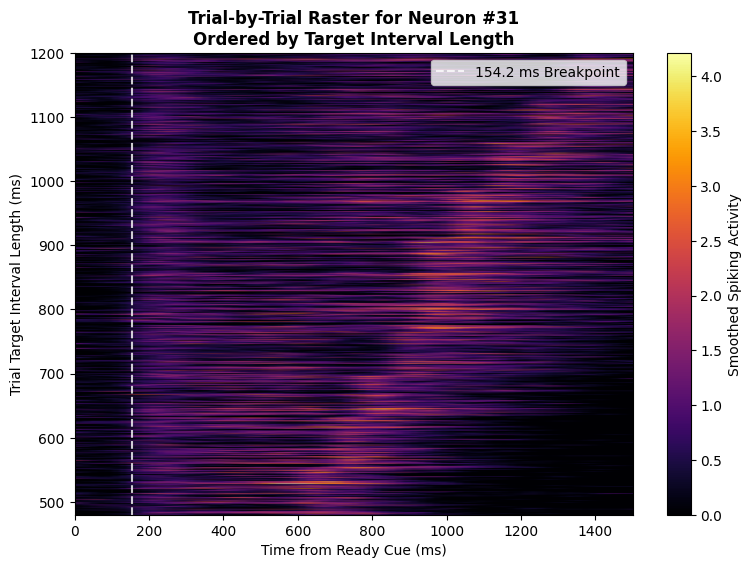

In [19]:
# Sort all 983 trials based on their target interval length (ts)
sorted_trial_indices = np.argsort(trial_conditions)
sorted_lfads = smoothed_input[sorted_trial_indices, :, :]

# Pick a representative neuron to view across all 983 individual trials
representative_neuron = top_neurons[-1]

plt.figure(figsize=(9, 6))
# Create a heatmap where each row is an individual trial, ordered by duration
plt.imshow(sorted_lfads[:, :, representative_neuron], cmap='inferno', aspect='auto',
           extent=[0, 75*20, trial_conditions.max(), trial_conditions.min()])

plt.colorbar(label='Smoothed Spiking Activity')
plt.gca().invert_yaxis() # Put shorter trials at the bottom, longer at the top
plt.axvline(x=154.2, color='white', linestyle='--', alpha=0.8, label='154.2 ms Breakpoint')

plt.title(f'Trial-by-Trial Raster for Neuron #{representative_neuron}\nOrdered by Target Interval Length', fontsize=12, weight='bold')
plt.xlabel('Time from Ready Cue (ms)')
plt.ylabel('Trial Target Interval Length (ms)')
plt.legend()
plt.show()

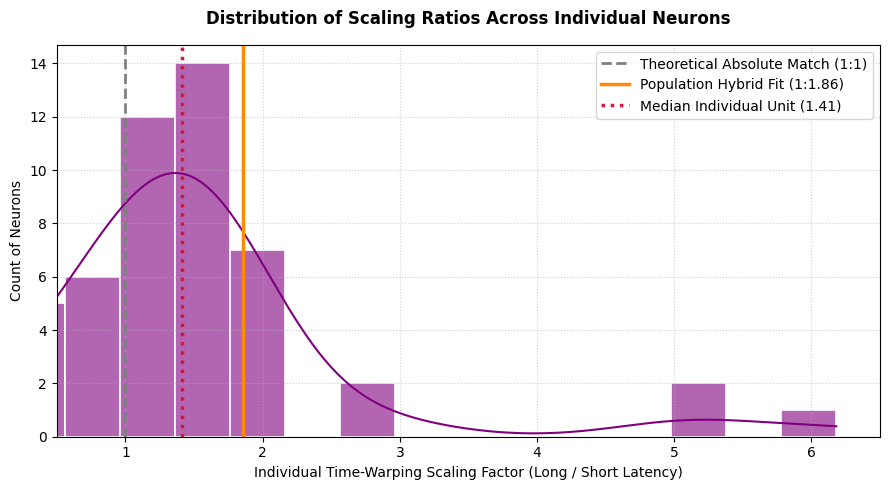

Total neurons peaking after the 154ms breakpoint: 49 out of 54
Percentage of timing-responsive neurons that scale (> 1.0): 71.4%


In [20]:
import seaborn as sns

# 1. Set up the plotting environment
plt.figure(figsize=(9, 5))

# 2. Plot the distribution of individual ratios
sns.histplot(data=scaling_neurons, x='Individual_Ratio', bins=15, 
             kde=True, color='purple', alpha=0.6, edgecolor='w', linewidth=1.2)

# 3. Add vertical reference lines for your global discoveries
plt.axvline(x=1.0, color='gray', linestyle='--', linewidth=2, 
            label='Theoretical Absolute Match (1:1)')
plt.axvline(x=1.86, color='darkorange', linestyle='-', linewidth=2.5, 
            label='Population Hybrid Fit (1:1.86)')

# 4. Highlight the median of the actual individual units
median_ratio = scaling_neurons['Individual_Ratio'].median()
plt.axvline(x=median_ratio, color='crimson', linestyle=':', linewidth=2.5, 
            label=f'Median Individual Unit ({median_ratio:.2f})')

# 5. Aesthetics
plt.title('Distribution of Scaling Ratios Across Individual Neurons', fontsize=12, weight='bold', pad=15)
plt.xlabel('Individual Time-Warping Scaling Factor (Long / Short Latency)')
plt.ylabel('Count of Neurons')
plt.xlim(0.5, 6.5)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)

plt.tight_layout()
plt.show()

# 6. Print a quick structural summary of the units
print(f"Total neurons peaking after the 154ms breakpoint: {len(scaling_neurons)} out of 54")
print(f"Percentage of timing-responsive neurons that scale (> 1.0): {((scaling_neurons['Individual_Ratio'] > 1.0).sum() / len(scaling_neurons)) * 100:.1f}%")